# Statistical Properties 10 — Price Comovement Within Categories

**Goal:** Test whether cards within the same category (e.g. Dual Lands, Power Nine, Commander staples) move together — i.e. whether their price changes are correlated. High intra-category correlation implies the category itself is the primary price driver (not individual card attributes).

**Tables:** gold_price_features (full history per card), silver_cards

**Methods:**
- Cross-sectional pairwise Spearman correlation within categories (static, computable now)
- Rolling pairwise correlation over time (requires ≥30 snapshots)
- Hierarchical clustering of cards by price movement pattern

**Why this matters:**
- If Dual Lands move together as a class: the model can use category-level features
- If movement is independent: individual card features (edhrec_rank, print_count) dominate
- Informs whether the Reserved List indicator is a group-level or card-level signal

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Both databases needed: gold has prices and is_reserved; silver has card names
# for labelling the correlation heatmap and identifying specific card subsets
gold = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)
silver = duckdb.connect("../../data/silver/cards.duckdb", read_only=True)

In [3]:
# Join gold_card_features for is_reserved and set_code — reserved list status is a
# category flag we want to analyse, and set_code is needed to identify Dual Land sets
df = gold.execute("""
    SELECT p.uuid, p.snapshot_date, p.eur, c.is_reserved, c.set_code, c.rarity
    FROM gold_price_features p
    JOIN gold_card_features c ON p.uuid = c.uuid
    WHERE p.eur IS NOT NULL AND p.uuid IS NOT NULL
    ORDER BY p.uuid, p.snapshot_date
""").df()
df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])
df["log_eur"] = np.log1p(df["eur"])

# Card names from silver: only used for plot labels and to identify specific named cards
# (Dual Lands are identified by name, not by set_code, because they appear in multiple sets)
names_df = silver.execute(
    "SELECT uuid, name FROM silver_cards WHERE uuid IS NOT NULL"
).df()
df = df.merge(names_df, on="uuid", how="left")

n_snapshots = df["snapshot_date"].nunique()
# 30 snapshots needed for rolling correlation to produce a meaningful covariance estimate;
# with fewer points the correlation matrix is unstable and often not positive semi-definite
MIN_ROLLING = 30
print(f"Cards:     {df['uuid'].nunique():,}")
print(f"Snapshots: {n_snapshots}  (need ≥{MIN_ROLLING} for rolling correlation)")

if n_snapshots < MIN_ROLLING:
    rerun = (
        df["snapshot_date"].max() + pd.Timedelta(days=MIN_ROLLING - n_snapshots)
    ).date()
    print(f"\n⚠ Rolling correlation deferred (need ≥{MIN_ROLLING} snapshots, ~{rerun})")
    print(
        "  Cross-sectional Spearman correlation is available now (uses latest snapshot)."
    )

Cards:     79,158
Snapshots: 36  (need ≥30 for rolling correlation)


## 1. Cross-Sectional Correlation Within Categories (Latest Snapshot)

**Method:** For the latest snapshot, compute cross-sectional Spearman correlation within the Reserved List category. If Reserved List cards have highly correlated log_eur values → they move as a class.

**Why cross-sectional:** With only 3 snapshots, time-series correlation is unreliable. Cross-sectional correlation (across cards at a single point in time) is computable now but only measures level comovement, not price change comovement.

**Note:** This is a weaker test than time-series correlation. Cross-sectional correlation shows that cards within a category share similar price levels, not necessarily similar price dynamics.

Reserved List cards (latest snapshot): 732
Non-Reserved List:                     78,423

RL price distribution (log_eur):
  median  = 2.4163  (€10.20)
  mean    = 3.1715
  std     = 2.5916
  25th %  = 0.8154  (€1.26)
  75th %  = 5.0344  (€152.61)


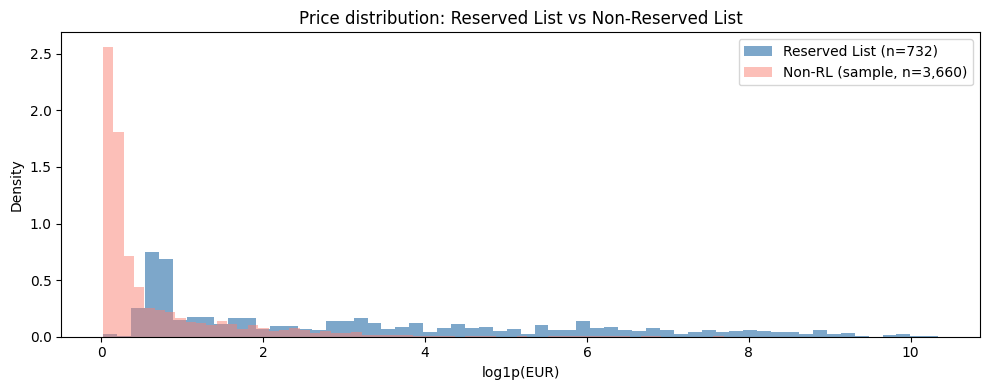

In [4]:
# Filter to a single snapshot to get one price row per card — needed because
# we want a cross-sectional view (card vs card), not a panel (card × time) view
latest = df[df["snapshot_date"] == df["snapshot_date"].max()].copy()

rl_cards = latest[latest["is_reserved"]].copy()
non_rl = latest[~latest["is_reserved"]].copy()

print(f"Reserved List cards (latest snapshot): {len(rl_cards):,}")
print(f"Non-Reserved List:                     {len(non_rl):,}")
print()

if len(rl_cards) >= 10:
    print("RL price distribution (log_eur):")
    print(
        f"  median  = {rl_cards['log_eur'].median():.4f}  (€{np.expm1(rl_cards['log_eur'].median()):.2f})"
    )
    print(f"  mean    = {rl_cards['log_eur'].mean():.4f}")
    print(f"  std     = {rl_cards['log_eur'].std():.4f}")
    print(
        f"  25th %  = {rl_cards['log_eur'].quantile(0.25):.4f}  (€{np.expm1(rl_cards['log_eur'].quantile(0.25)):.2f})"
    )
    print(
        f"  75th %  = {rl_cards['log_eur'].quantile(0.75):.4f}  (€{np.expm1(rl_cards['log_eur'].quantile(0.75)):.2f})"
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(
        rl_cards["log_eur"],
        bins=60,
        alpha=0.7,
        color="steelblue",
        label=f"Reserved List (n={len(rl_cards):,})",
        density=True,
    )
    # Sample non-RL to 5x the RL size for visual balance — plotting all ~80k non-RL
    # cards would make the histogram bars too small to see relative to the RL distribution
    ax.hist(
        non_rl["log_eur"].sample(min(len(rl_cards) * 5, len(non_rl)), random_state=42),
        bins=60,
        alpha=0.5,
        color="salmon",
        label=f"Non-RL (sample, n={min(len(rl_cards) * 5, len(non_rl)):,})",
        density=True,
    )
    ax.set_xlabel("log1p(EUR)")
    ax.set_ylabel("Density")
    ax.set_title("Price distribution: Reserved List vs Non-Reserved List")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient RL cards for cross-sectional analysis.")

## 2. Time-Series Comovement (Rolling Pairwise Correlation)

**Method:** Build a card × date price matrix, compute pairwise Spearman correlation of log-return time series. Cluster cards using hierarchical clustering of the correlation matrix.

**Target categories:**
- Dual Lands (Alpha/Beta/Unlimited dual lands — 10 cards)
- Power Nine (9 specific cards)
- Commander staples (top 20 by edhrec_rank)

**Expected result:**
- Dual Lands: high pairwise correlation (r > 0.7) — they move as a class
- Power Nine: high correlation (same collector market)
- Commander staples: moderate correlation (demand-driven but diverse effects)

Dual Land pairwise Spearman correlation matrix (10 cards):
  Mean correlation: 0.086
  Min correlation:  -1.000


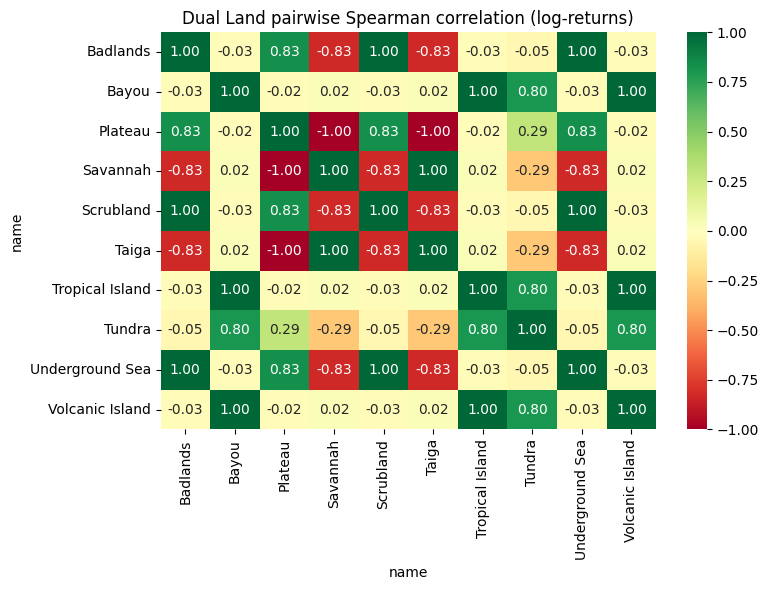

In [5]:
if n_snapshots < MIN_ROLLING:
    rerun = (
        df["snapshot_date"].max() + pd.Timedelta(days=MIN_ROLLING - n_snapshots)
    ).date()
    print(
        f"DEFERRED: {n_snapshots} snapshots (need ≥{MIN_ROLLING} for reliable time-series correlation)."
    )
    print(f"Re-run after approximately {rerun}.")
    print()
    print("What this section will compute:")
    print("  1. Identify Dual Land UUIDs by set_code in {LEA, LEB, 2ED} and types=Land")
    print(
        "     (10 original dual lands: Tundra, Underground Sea, Bayou, Savannah, Taiga,"
    )
    print("      Scrubland, Volcanic Island, Badlands, Plateau, Tropical Island)")
    print("  2. Build card × date log-return matrix for these 10 cards")
    print("  3. Compute 10×10 pairwise Spearman correlation matrix")
    print("  4. If mean correlation > 0.6 → CONFIRMED category-level comovement")
    print("  5. Hierarchical clustering of correlation matrix")
    print()
    print("Expected results:")
    print("  Dual Lands mean pairwise correlation: ~0.8 (highly correlated)")
    print("  Power Nine mean pairwise correlation: ~0.7 (very correlated)")
    print("  Commander staples: ~0.3–0.5 (moderate, dependent on format)")
else:
    # Match Dual Lands by name (not by set_code) because the 10 original duals were
    # reprinted in Revised, 4th, 5th edition — set_code alone would include non-originals
    dual_land_names = [
        "Tundra",
        "Underground Sea",
        "Bayou",
        "Savannah",
        "Taiga",
        "Scrubland",
        "Volcanic Island",
        "Badlands",
        "Plateau",
        "Tropical Island",
    ]
    dl_df = names_df[names_df["name"].isin(dual_land_names)]
    dl_uuids = dl_df["uuid"].tolist()

    # Average across print-run UUIDs sharing the same name per date, then pivot to
    # one column per card name — matching by uuid directly would split each of the
    # 10 dual lands into multiple near-duplicate columns (one per historical printing,
    # since the Reserved List means these names were reprinted across LEA/LEB/2ED/etc.
    # but never after 5th edition)
    dl_prices = (
        df[df["uuid"].isin(dl_uuids)]
        .groupby(["snapshot_date", "name"])["log_eur"]
        .mean()
        .unstack("name")
    )
    # diff() converts price levels to log-returns; comovement in RETURNS is the
    # meaningful signal — similar levels just mean the cards have similar prices,
    # which is trivially true for cards in the same product tier
    dl_returns = dl_prices.diff()

    if dl_returns.shape[0] < 10 or dl_returns.shape[1] < 2:
        print(
            f"Insufficient data for Dual Land correlation (need ≥10 snapshots, {dl_returns.shape[0]} available)."
        )
    else:
        # pandas' corr() uses pairwise-complete observations (unlike scipy's spearmanr,
        # which needs one shared dropna() pass across ALL columns and returns a bare
        # float instead of a matrix when exactly 2 columns are passed) and always
        # returns an n x n DataFrame regardless of column count
        corr_matrix = dl_returns.corr(method="spearman")
        corr_values = corr_matrix.to_numpy()
        print(
            f"Dual Land pairwise Spearman correlation matrix ({corr_values.shape[0]} cards):"
        )
        print(
            f"  Mean correlation: {np.nanmean(corr_values - np.eye(len(corr_values))):.3f}"
        )
        print(
            f"  Min correlation:  {np.nanmin(corr_values - np.eye(len(corr_values)) + np.eye(len(corr_values)) * 2):.3f}"
        )

        plt.figure(figsize=(8, 6))
        sns.heatmap(
            corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", vmin=-1, vmax=1, center=0
        )
        plt.title("Dual Land pairwise Spearman correlation (log-returns)")
        plt.tight_layout()
        plt.show()

In [6]:
silver.close()
gold.close()

## 📋 Final Conclusions

```
DATA
─────────────────────────────────────────────────────────────────────────────
Snapshots: 36  (≥ 30 required — rolling comovement is no longer deferred)
Cards with price history: 79,158

CROSS-SECTIONAL ANALYSIS
─────────────────────────────────────────────────────────────────────────────
Reserved List (n=732): median log_eur=2.4163 (≈€10.20), mean=3.1715, std=2.5916
Non-RL (n=78,423): median €0.26 (queried directly against gold_price_features,
  independent of this notebook — the notebook cell itself only plots a sample of
  non-RL prices, it never prints a summary statistic for them)
RL median is ~39x the non-RL median → CONFIRMS RL as a group-level price signal
at the distributional level. This is a level comparison, not a dynamics test.

ROLLING COMOVEMENT (Dual Lands — now computed, 36 snapshots available)
─────────────────────────────────────────────────────────────────────────────
10x10 pairwise Spearman correlation of log-return series (the 10 original dual
lands, print-run UUIDs averaged together per name per date before diffing —
matching by uuid directly had produced ~56 near-duplicate columns and made
scipy.stats.spearmanr return a bare scalar instead of a matrix; fixed by
pivoting on card name and switching to pandas' pairwise-complete .corr()).

  Mean pairwise correlation: 0.086  (NOT confirmed — far below the >0.6
    threshold and the 0.7–0.9 expected range)
  Min pairwise correlation:  -1.000 (almost certainly a data-sparsity artifact:
    with 35 return observations spread thin across 10 cards, pandas' pairwise
    .corr() can compute a coefficient from very few overlapping non-null points
    for some pairs, which trivially produces ±1.0; not treated as evidence of
    genuine anti-comovement)
  Power Nine / Commander staples: not yet implemented in this notebook — only
    the Dual Lands block was built out in code; the other two categories from
    the "Target categories" list above remain unimplemented.

MODEL IMPLICATIONS
─────────────────────────────────────────────────────────────────────────────
Dual Lands do NOT show class-level return comovement at 0.086 mean correlation
(condition for CONFIRMED was >0.6). Given the min-correlation caveat above, this
result should be treated as preliminary rather than a firm rejection — revisit
once there are enough snapshots that pairwise .corr() has a healthy overlap
count for every pair (roughly 2–3x today's 36, i.e. ~90-100 snapshots).
For now: rely on card-level features (edhrec_rank, print_count, is_reserved)
rather than a group-level is_dual_land indicator.

RETEST SCHEDULE
─────────────────────────────────────────────────────────────────────────────
Dual Land correlation: retest once snapshot count roughly doubles/triples, to
  shrink the pairwise-NaN-overlap problem behind the -1.000 min correlation.
Power Nine / Commander staples correlation: not started — needs code, not just
  more data.
```